In [658]:
import torch
import sys
from torch.func import jacrev, jacfwd, vjp, vmap
from torch.autograd import grad
import numpy as np
sys.path.append("../scripts/")
from astropy.io import fits
from astropy.coordinates import SkyCoord
from torchvision import transforms
import torch.nn.functional as F
from torch.func import jvp
import h5py
from tqdm import tqdm
from astropy import units
from forward_model import make_forward_model, make_wcs, WCS, DEVICE, interpolate

def moving_average_and_confidence(data, window_size=50):
    cumsum = np.cumsum(data)
    cumsum[window_size:] = cumsum[window_size:] - cumsum[:-window_size]
    moving_avg = cumsum[window_size - 1:] / window_size
    std_err = np.std(data[:window_size]) / np.sqrt(window_size)
    upper_confidence = moving_avg + 1.96 * std_err
    lower_confidence = moving_avg - 1.96 * std_err
    return moving_avg, upper_confidence, lower_confidence

In [659]:
def noise_padding_fn(x, pad, sigma):
    B, C, H, W = x.shape
    PU, PD, PL, PR = pad
    out = torch.zeros(1, 1, H+PU+PD, W+PL+PR)
    # Put x in the center of the padded model
    out[..., PD:H+PU, PL:W+PR] = x
    # Create a mask for padding region
    mask = torch.ones_like(out)
    mask[..., PD:H+PU, PL:W+PR] = 0.
    # Noise pad around the model
    z = torch.randn_like(out) * sigma
    out += z * mask
    return out

In [660]:
def make_forward_model(
        psf:np.ndarray, 
        wcs_list:list[WCS, ...], 
        psf_super_sampling_factor:int,
        model_super_sampling_factor:int,
        model_pixels:int,
        model_pixel_size:units.Quantity,
        zero_padding:int=0,
        fiducial_center:SkyCoord=None,
        fiducial_orientation:float=None, # Pick the orientation of the first WCS, angle East of North
        sum_pool=True,
        **kwargs
        ):
    """
    Create a forward model for a given point spread function (PSF) and a list of world coordinate systems (WCS).

    Parameters:
    -----------
    psf : np.ndarray
        The point spread function (PSF) to be used for the forward model. It should be a 2D or 3D array (multi channel fit).

    wcs_list : list[WCS, ...]
        A list of world coordinate systems (astropy WCS) to be used for the forward model. 

    psf_super_sampling_factor : int
        The super sampling factor to be used for the forward model. It determines the level of detail in the model.

    model_super_sampling_factor : int
        The super sampling factor to be used for the forward model. It determines the level of detail in the model.

    model_pixels : int
        The number of pixels to be used for the model pixel grid.

    model_pixel_size : units.Quantity
        The size of each pixel in the model pixel grid. It should be an instance of the units.Quantity class.

    zero_padding : int, optional
        The number of zero padding pixels to be added to the model pixel grid on each side. Default is 0.

    fiducial_center : SkyCoord, optional
        The fiducial center to be used for the model reference pixel. It should be an instance of the SkyCoord class. 
        Default (None) is to use first WCS center pixel world coordinate.
        
    fiducial_orientation : float, optional
        The fiducial orientation to be used for model pixel grid. The angle is defined East of North. 
        Default (None) is to use first WCS pixel scale matrix orientation.

    Returns:
    --------
    forward_model : np.ndarray
        The created forward model as a 2D array.

    Examples:
    ---------
    >>> psf = np.ones((5, 5))
    >>> wcs_list = [WCS(), WCS()]
    >>> super_sampling_factor = 2
    >>> model_pixels = 10
    >>> model_pixel_size = units.Quantity(0.1, 'arcsec')
    >>> forward_model = make_forward_model(psf, wcs_list, super_sampling_factor, model_pixels, model_pixel_size)
    """

    if psf.ndim == 2:
        C = 1
        H, W = psf.shape
    elif psf.ndim == 3:
        C, H, W = psf.shape
    psf = torch.tensor(psf).float().to(DEVICE).view(C, 1, H, W) # reshape to a convolution kernel [channel_out, channels_in/groups, H, W]
    batched_interpolation = vmap(interpolate, in_dims=(0, None))  # only batch over the images (first argument of interpolate)
    
    # Create Fiducial WCS for the model
    if fiducial_center is None:
        # Use same convention as Cutout2D for reference pixel (assuming dim is even)
        center = [dim / 2 - 1  for dim in wcs_list[0].pixel_shape]
        fiducial_center = wcs_list[0].pixel_to_world(*center)
    if fiducial_orientation is None:
        pc = wcs_list[0].pixel_scale_matrix
        fiducial_orientation = np.arctan2(pc[1, 0], pc[0, 0]) * 180 / np.pi
    fiducial_wcs = make_wcs(fiducial_center, fiducial_orientation, model_pixels, model_pixel_size)
    print("Fiducial WCS")
    print(fiducial_wcs)
    

    model_kernel = model_super_sampling_factor / psf_super_sampling_factor
    ssf = psf_super_sampling_factor
    szp = ssf * zero_padding
    # Prepare Drizzle coordinate systems
    coordinates_list = []
    for wcs in wcs_list:
        u = np.arange(-szp, ssf * wcs.pixel_shape[0] + szp) / ssf
        v = np.arange(-szp, ssf * wcs.pixel_shape[1] + szp) / ssf
        u, v = np.meshgrid(u, v, indexing="ij")
        world = wcs.pixel_to_world(u, v)
        coordinates = np.stack(fiducial_wcs.world_to_pixel(world), axis=0)
        coordinates_list.append(torch.tensor(coordinates).float().to(DEVICE))
    
    def A(x):
        ys = []
        for i in range(len(wcs_list)):
            y = batched_interpolation(x, coordinates_list[i]) * (model_kernel**2 if sum_pool else 1.)
            y = F.conv2d(y, psf, groups=C, padding="same")
            # Pool the convolved flux to observation grid
            y = F.avg_pool2d(y, kernel_size=psf_super_sampling_factor, divisor_override=1 if sum_pool else None)
            # Crop out the zero padding to remove edge effects from the convolution
            pi, pj = wcs_list[i].pixel_shape
            zp = zero_padding
            y = y[..., zp:pi+zp, zp:pj+zp]
            ys.append(y)
        return torch.concat(ys, dim=1)
    return A

Fiducial WCS
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 10.00001478024554  19.99998611111051  
CRPIX : 159.0  159.0  
PC1_1 PC1_2  : 1.73611111111111e-06  0.0  
PC2_1 PC2_2  : 0.0  -1.7361111111111e-06  
CDELT : 1.0  1.0  
NAXIS : 320  320


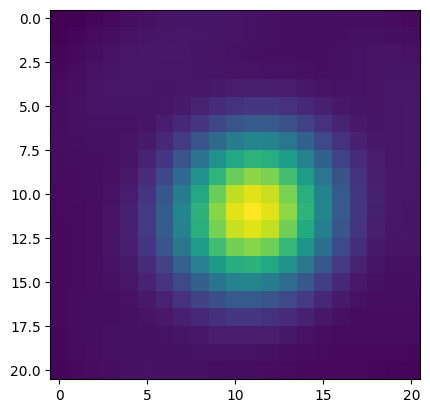

In [721]:
# Now we test this idea on the actual forward model
coord = SkyCoord(ra=10*units.deg, dec=20*units.deg)
psf_ssf = 4
observation_pixels = 32
model_pixels = 256
noise_padding = 32
pixels = model_pixels + 2 * noise_padding
factor = model_pixels / observation_pixels
observation_pixel_size = 0.05
# In order to avoid edge effects in the observation, we zero pad the observation
model_pixel_size = 0.05 / factor
zero_padding = 8 # of the observation
model_ssf = model_pixels // observation_pixels
factor = psf_ssf / model_ssf



wcs = make_wcs(coord, orientation=0, pixels=observation_pixels, pixel_size=observation_pixel_size * units.arcsec)
wcs_list = [wcs]
with fits.open("../data/F814w_WFC3UV_psf.fits") as data:
    p = 21 // 2
    c = 101 // 2
    psf = data["PRIMARY"].data.astype(np.float32)[c-p-1: c+p, c-p-1: c+p][None]
    psf /= psf.sum()
    # psf = data["PRIMARY"].data.astype(np.float32)[None]
plt.imshow(psf[0])
    
# sigma = 0.1
# x = np.linspace(-1, 1, 101)
# xx, yy = np.meshgrid(x, x)
# rsq = xx**2 + yy**2
# psf = np.exp(-0.5 * rsq / sigma**2)
# psf /= psf.sum()
# plt.imshow(psf)
# psf = psf[None]

forward_model = make_forward_model(
        psf, 
        wcs_list, 
        psf_super_sampling_factor=psf_ssf,
        model_super_sampling_factor=model_ssf,
        model_pixels=pixels,
        model_pixel_size=model_pixel_size * units.arcsec,
        zero_padding=zero_padding,
        sum_pool=True, # Use average pool for SKIRT prior!
        fiducial_orientation=0
)

x = torch.randn(size=[1, 1, model_pixels, model_pixels])
# A = jacrev(forward_model)(x)
# print(A.shape)
# A = A.view(observation_pixels**2, model_pixels**2)

torch.Size([1, 1, 32, 32]) tensor(0.9530)


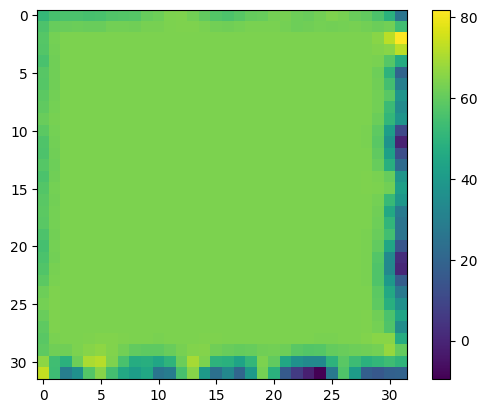

In [722]:
x = torch.ones(1, 1, model_pixels, model_pixels)
x = noise_padding_fn(x, [noise_padding]*4, sigma=5)

# x = torch.ones(1, 1, pixels, pixels)
y = forward_model(x)


# Use this mask in inference to conver only the region where residuals follow the right statistics
# mask = (y / model_ssf**2) >= 0.99
plt.imshow(y.squeeze())
# plt.imshow(mask.squeeze())
plt.colorbar()
print(y.shape, y.sum() / model_pixels**2)

# Effective kernel

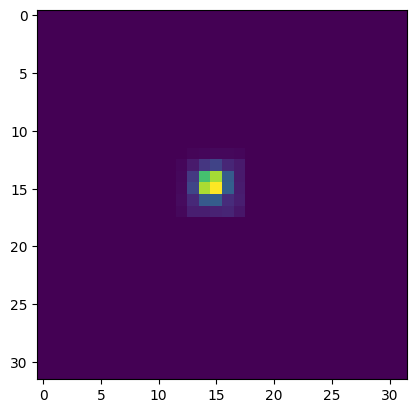

In [723]:
x = torch.randn(size=[1, 1, pixels, pixels])
v = torch.zeros_like(x)
v[0, 0, pixels//2, pixels//2] = 1
_, kernel = jvp(forward_model, (x, ), (v, ))
kernel = kernel[0, 0]

plt.imshow(kernel)

# Simulate diffusion with transition kernel

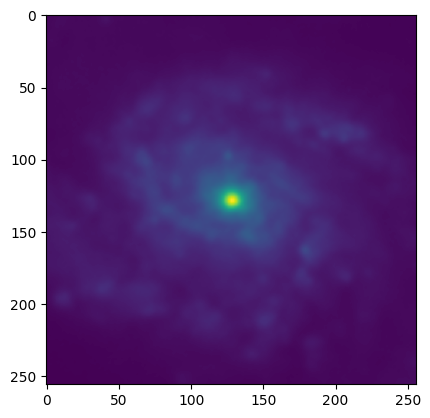

In [724]:
source = torch.tensor(h5py.File("../data/probes.h5")["galaxies"][101, ..., 0]).float()[None, None]

# Test if using the wrong prior still works (take index = 200 or 1002 for example)
source_for_prior = torch.tensor(h5py.File("../data/probes.h5")["galaxies"][101, ..., 0]).float()[None, None]
noise = torch.tensor(np.load("../data/connor_targets_flat_fields_noise_cutouts.npy")[102]).float()[None, None]

source = F.avg_pool2d(source, 256//model_pixels)
source_for_prior = F.avg_pool2d(source_for_prior, 256//model_pixels)

noise = transforms.CenterCrop(observation_pixels)(noise)


sde = "VE"
plt.imshow(source_for_prior.squeeze())

In [568]:
if sde == "VP":

    beta_min = 1e-2
    beta_max = 20
    T = 1
    epsilon = 1e-2

    def beta(t):
        return beta_min + (beta_max - beta_min) * t

    def f(x, t):
        return -0.5 * beta(t).view(-1, 1, 1, 1) * x

    def g(t):
        return torch.sqrt(beta(t).view(-1, 1, 1, 1))

    def forward(x, t, dt):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(dt)
        return x + f(x, t) * dt + g(t) * dw

    def backward(x, t, dt, score_fn):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(-dt)
        return x + (f(x, t) - g(t)**2 * score_fn(x, t))*dt + g(t) * dw

    def sigma(t):
        log_coeff = 0.5 * (beta_max - beta_min) * t ** 2 + beta_min * t
        std = torch.sqrt(1. - torch.exp(-log_coeff))
        return std.view(-1, 1, 1, 1)

    def mu(t):
        log_coeff = 0.5 * (beta_max - beta_min) * t ** 2  + beta_min * t
        return torch.exp(-0.5*log_coeff).view(-1, 1, 1, 1)

    t = torch.linspace(epsilon, T, 100)
    plt.plot(t, sigma(t).squeeze(), label=r"$\sigma(t)$")
    plt.plot(t, mu(t).squeeze(), label=r"$\mu(t)$")
    plt.legend()
    plt.ylabel("Scale")
    plt.xlabel("t")
    plt.yscale("log")
    # plt.xscale("log")

$$
    \mathcal{N}(\mu_t x_0, \sigma_t^2)
$$

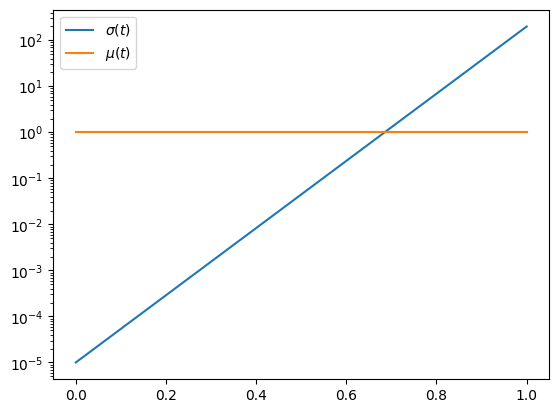

In [400]:
if sde == "VE":
    sigma_max = 200
    sigma_min = 1e-5
    T = 1
    epsilon = 0

    def sigma(t):
        return sigma_min * (sigma_max / sigma_min)**t

    def f(x, t):
        return 0.
    
    def mu(t):
        return torch.ones_like(t).view(-1, 1, 1, 1)

    def g(t):
        return sigma(t).view(-1, 1, 1, 1) * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

    def forward(x, t, dt):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(dt)
        return x + f(x, t) * dt + g(t) * dw

    def backward(x, t, dt, score_fn):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(-dt)
        return x + (f(x, t) - g(t)**2 * score_fn(x, t))*dt + g(t) * dw
    
    t = torch.linspace(epsilon, T, 100)
    plt.plot(t, sigma(t).squeeze(), label=r"$\sigma(t)$")
    plt.plot(t, mu(t).squeeze(), label=r"$\mu(t)$")
    plt.legend()
    plt.yscale("log")

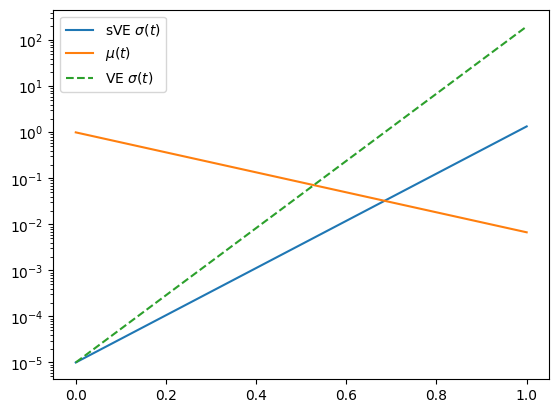

In [556]:
if sde == "sVE": # Actually equivalent to beta_max = 0 and beta_min = t_star
    sigma_max = 200
    sigma_min = 1e-5
    epsilon = 0
    T = 1
    beta_min = 5 # in relation to the VP sde
    
    def scale(t):
        return torch.exp(- beta_min * t)
    
    def scale_dot(t):
        return - scale(t) * beta_min

    def sigma(t):
        return scale(t) * sigma_min * (sigma_max / sigma_min)**t
    
    def mu(t):
        return scale(t).view(-1, 1, 1, 1)

    def f(x, t):
        return - beta_min * x # simplified drift coefficient from scale_dot(t) / scale(t)

    def g(t):
        return sigma(t).view(-1, 1, 1, 1) * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

    def forward(x, t, dt):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(dt)
        return x + f(x, t) * dt + g(t) * dw

    def backward(x, t, dt, score_fn):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(-dt)
        return x + (f(x, t) - g(t)**2 * score_fn(x, t))*dt + g(t) * dw
    
    t = torch.linspace(epsilon, T, 100)
    plt.plot(t, sigma(t).squeeze(), label=r"sVE $\sigma(t)$")
    plt.plot(t, mu(t).squeeze(), label=r"$\mu(t)$")
    plt.plot(t, sigma_min * (sigma_max / sigma_min)**t, ls="--", label=r"VE $\sigma(t)$")
    plt.legend()
    plt.yscale("log")

23.025850929940457


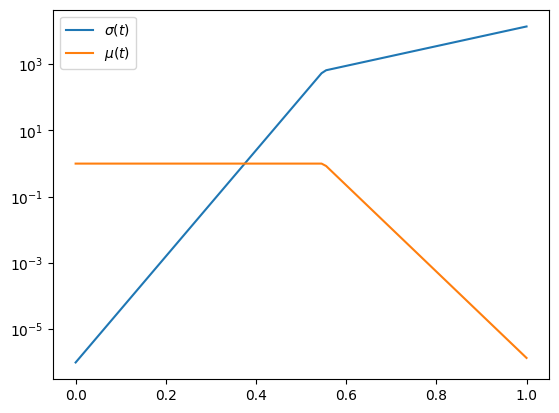

In [303]:
if sde == "tsVE": # Actually equivalent to beta_max = 0 and beta_min = t_star
    sigma_max = 1e10 # most extreme case that we get with SKIRT
    sigma_min = 1e-6 # Note that for training, sigma min should be made to be 1/sigma_max or close to it 
                     # to even out the log uniform distribution
    epsilon = 0
    T = 1
    t_star = .55 # When we start to apply the scaling 
    beta_min = 20  #np.log(sigma_max)
    print(np.log(sigma_max))  # A good guess for beta_min is the natural log of sigma_max, see sigma (see stable formulation of sigma)
    
    def scale(t):
        return torch.exp(- beta_min * (torch.maximum(t_star*torch.ones_like(t), t) - t_star))
    
    def scale_dot(t):
        return - scale(t) * beta_min

    def sigma(t):
        smin = np.log(sigma_min)
        smax = np.log(sigma_max)
        log_coeff = - beta_min * (torch.maximum(t_star*torch.ones_like(t), t) - t_star)
        log_coeff += t * (smax - smin) + smin
        return torch.exp(log_coeff) # numerically stable sigma
        # return scale(t) * sigma_min * (sigma_max / sigma_min)**t # unstable for crazy sigma_min and sigma_max
    
    def mu(t):
        return scale(t).view(-1, 1, 1, 1)

    def f(x, t):
        # A bit of a hack to account fo- beta_min * (torch.maximum(t_star*torch.ones_like(t), t) - t_star))r the step function when the drift turns off
        if t[0].item() > t_star:
            return - beta_min * x  # simplified drift coefficient from scale_dot(t) / scale(t)
        else:
            return 0.

    def g(t):
        return sigma(t).view(-1, 1, 1, 1) * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

    def forward(x, t, dt):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(dt)
        return x + f(x, t) * dt + g(t) * dw

    def backward(x, t, dt, score_fn):
        dw = torch.randn(1, 1, model_pixels, model_pixels) * np.sqrt(-dt)
        return x + (f(x, t) - g(t)**2 * score_fn(x, t))*dt + g(t) * dw
    
    t = torch.linspace(epsilon, T, 100)
    plt.plot(t, sigma(t).squeeze(), label=r"$\sigma(t)$")
    plt.plot(t, mu(t).squeeze(), label=r"$\mu(t)$")
    plt.legend()
    plt.yscale("log")

In [725]:
C = 0.1
observation = forward_model(noise_padding_fn(C * source, [noise_padding]*4, sigma=0)) + noise

x0 = source_for_prior
def prior_score(x, t):
    return - (x - mu(t) * x0) / sigma(t)**2

z0 = noise
Lambda = torch.abs(torch.fft.fft2(kernel))**2
low_pass = Lambda[0, 0] / 50
Lambda_inv = 1/(Lambda + low_pass)

def noise_score(z, t):
    z_prime = torch.fft.fft2(z - mu(t) * z0)
    score_prime = z_prime / sigma(t)**2 * Lambda_inv
    score = -torch.fft.ifft2(score_prime).real
    return score

def slic_score(x, t):
    x = noise_padding_fn(x, [noise_padding]*4, sigma=sigma(t).item())
    y_hat, vjp_func = vjp(lambda _x: forward_model(C * _x), x) # apply the link function
    z = mu(t) * observation - y_hat
    score = noise_score(z, t) # Rescale for the slic model to map back to learned space
    score = - vjp_func(score)[0]
    # crop back the score, we do this because padding inside vjp is unstable...
    m = model_pixels
    np = noise_padding
    return score[..., np:m+np, np:m+np] / C**2


prior_stats = {"max": [], "norm": []}
slic_stats = {"max": [], "norm": []}
def score_fn(x, t):
    ps = prior_score(x, t)
    ss = slic_score(x, t)
    prior_stats["norm"].append(np.linalg.norm(sigma(t) * ps.numpy().ravel()))
    slic_stats["norm"].append(np.linalg.norm(sigma(t) * ss.numpy().ravel()))
    prior_stats["max"].append(sigma(t).squeeze().numpy() * ps.max().item())
    slic_stats["max"].append(sigma(t).squeeze().numpy() * ss.max().item())
    return ps + ss

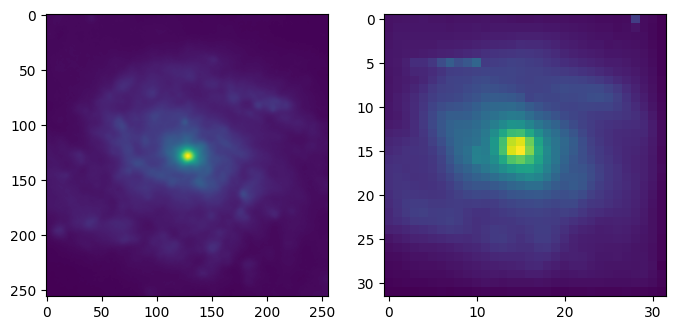

In [726]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(source_for_prior.squeeze())
axs[1].imshow(observation.squeeze())

In [727]:
B = 1
N = 1000

x = torch.randn([B, 1, model_pixels, model_pixels]) * sigma(torch.ones(1))
prior_stats = {"max": [], "norm": []}
slic_stats = {"max": [], "norm": []}

# Learned reverse SDE
chain = [x]
t = torch.ones([B])*T
dt = -(T - epsilon)/N
ts = [t[0].item()]
with torch.no_grad():
    for n in tqdm(range(N)):
        t += dt
        if t[0] < epsilon:
            break  
        ts.append(t[0].item())
        x = backward(x, t, dt, score_fn)
        chain.append(x.numpy())
chain = np.stack(chain, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:41<00:00, 24.16it/s]


Text(0.5, 0, 't')

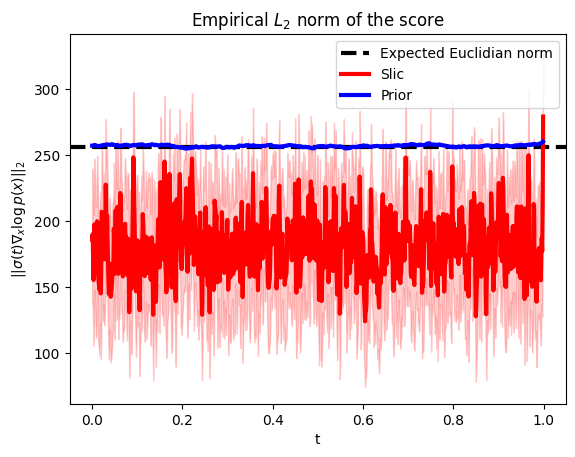

In [728]:
ts = np.linspace(0, T, len(prior_stats["norm"]))


window_size = 2
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
# plt.yscale("log")
# plt.ylim(1, 1e3)


# =============== VP SDE ===================

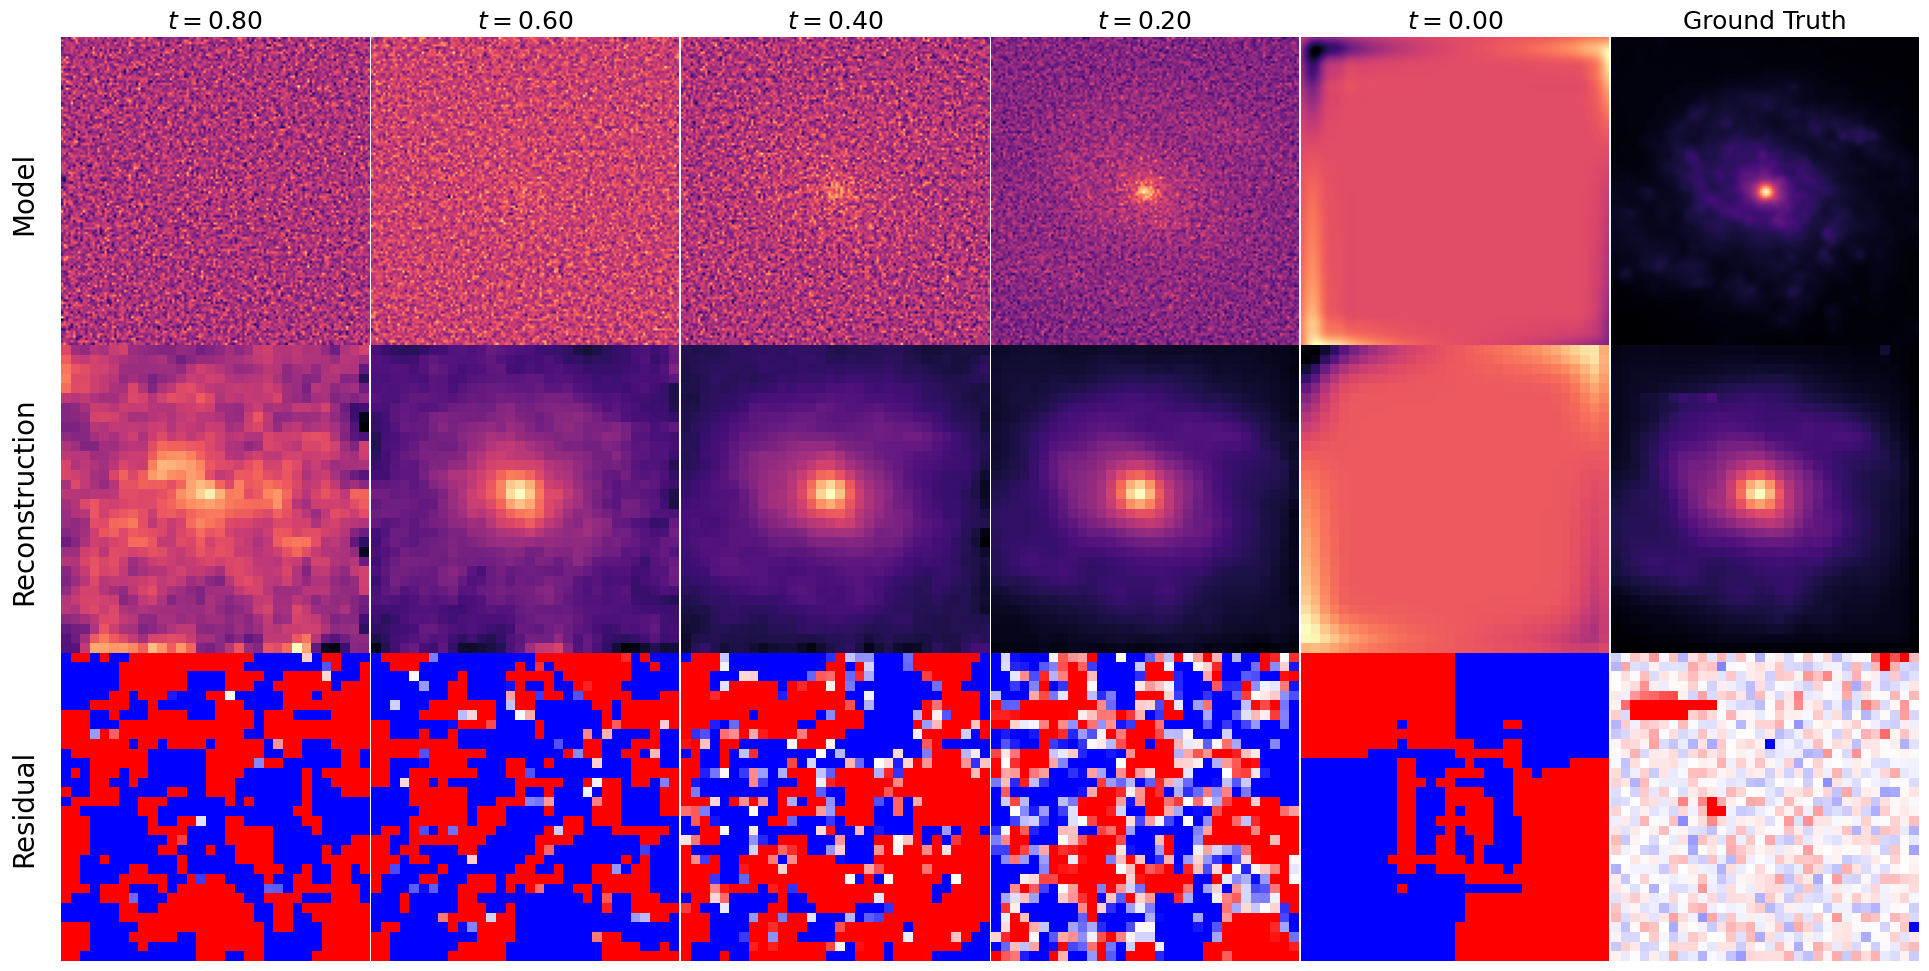

In [536]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(_x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

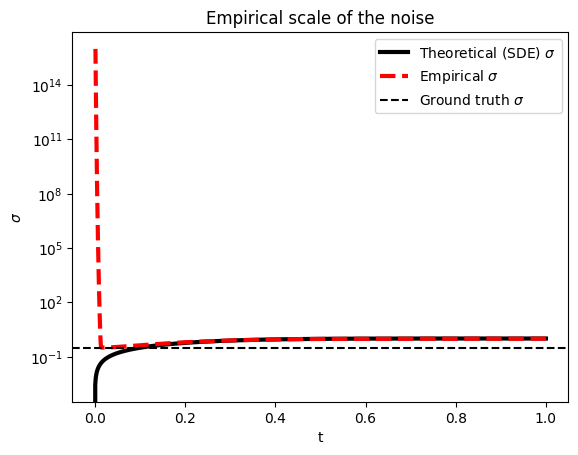

In [537]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

(0.0, 192.0)

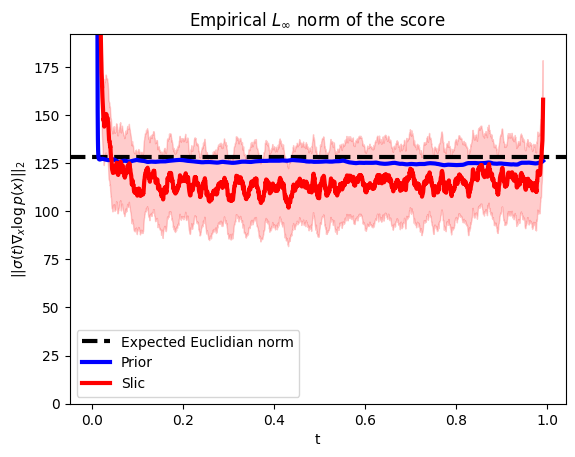

In [538]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")
plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)
plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
plt.ylim(0, 1.5 * model_pixels)

(0.0, 8.0)

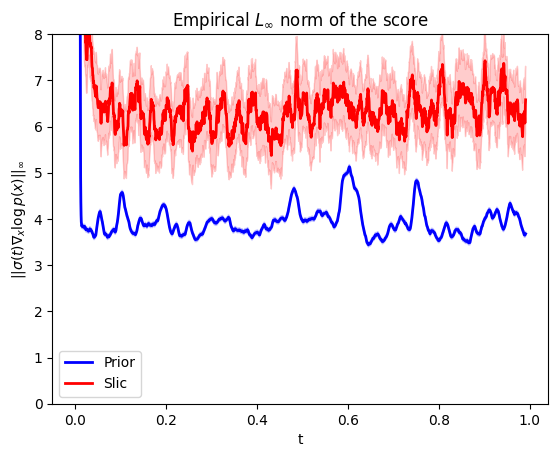

In [539]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["max"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["max"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_\infty$ norm of the score")
plt.plot(ts_shifted, prior_mavg, "b-", lw=2, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)
plt.plot(ts_shifted, slic_mavg, "r-", lw=2, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_\infty$")
plt.legend()
plt.xlabel("t")
plt.ylim(0, 8)

# =============== VE SDE ===================

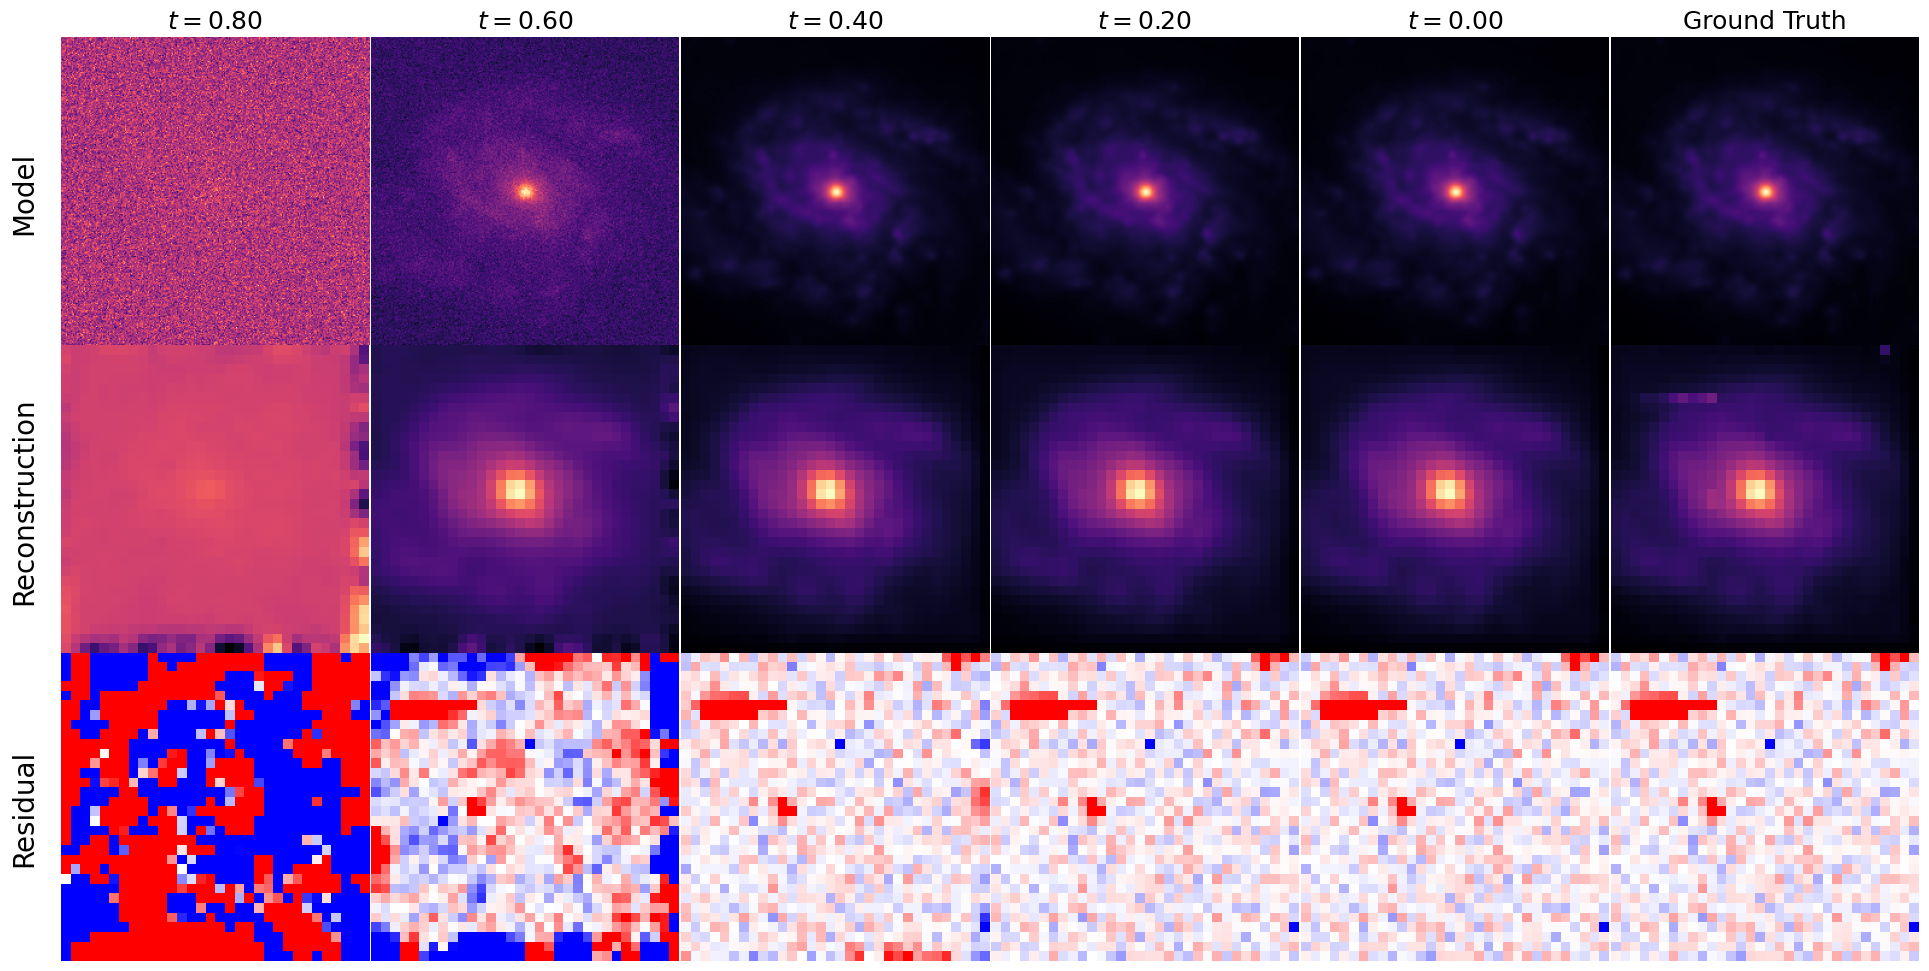

In [685]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(C * _x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

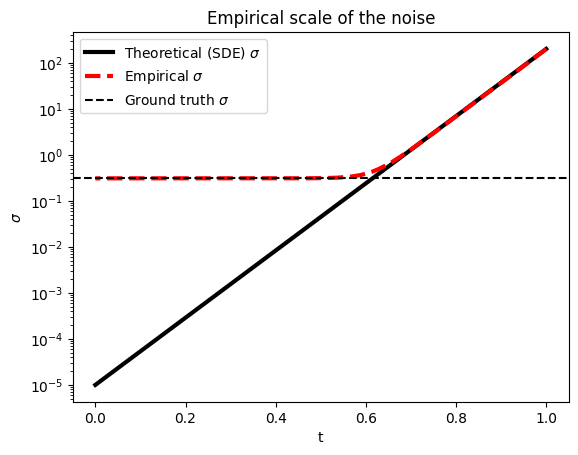

In [686]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

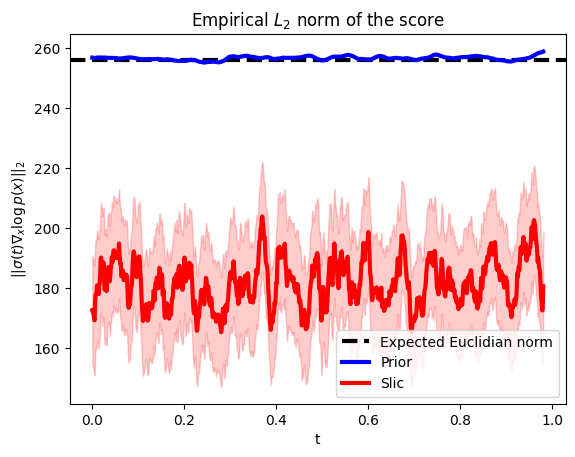

In [683]:
ts = np.linspace(0, T, len(prior_stats["norm"]))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")
plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)
plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
plt.show()


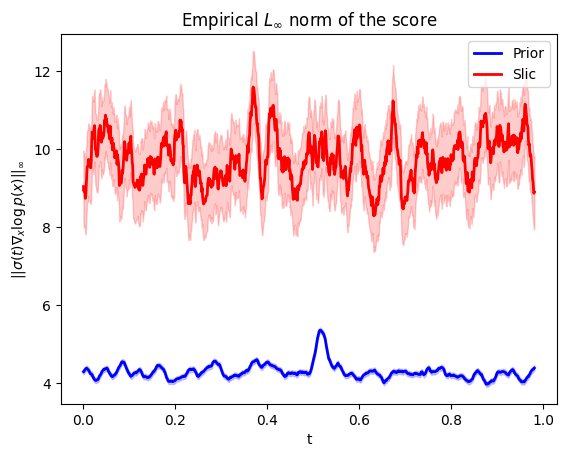

In [684]:
ts = np.linspace(0, T, len(prior_stats["norm"]))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["max"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["max"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_\infty$ norm of the score")
plt.plot(ts_shifted, prior_mavg, "b-", lw=2, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)
plt.plot(ts_shifted, slic_mavg, "r-", lw=2, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_\infty$")
plt.legend()
plt.xlabel("t")
plt.show()

# =============== sVE SDE ===================

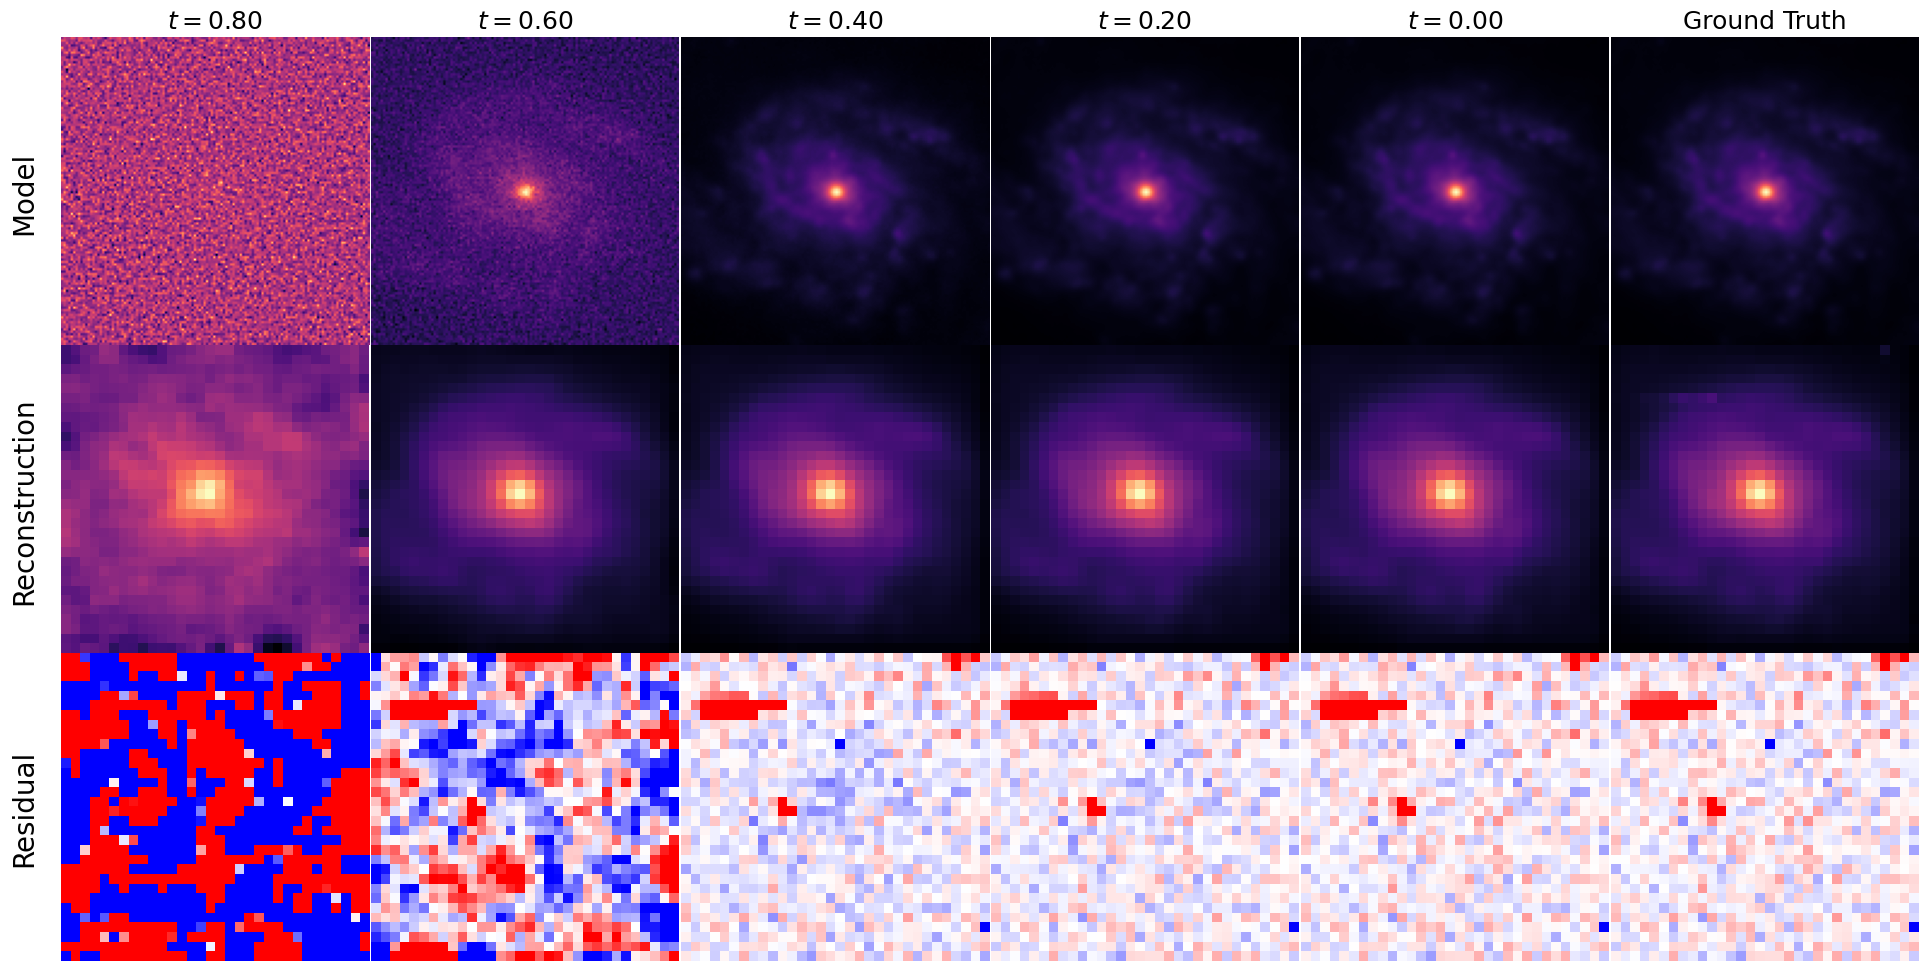

In [526]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(_x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

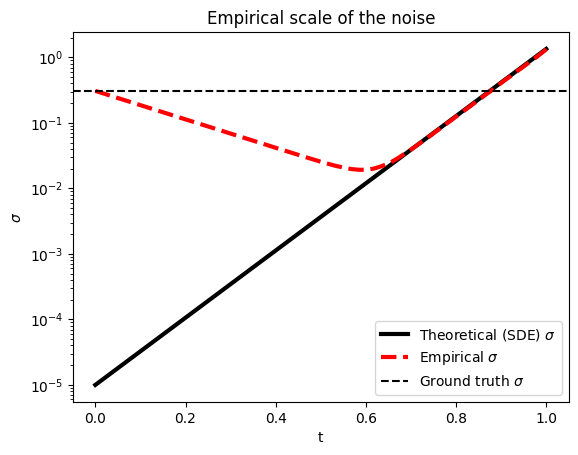

In [527]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

(50.0, 200.0)

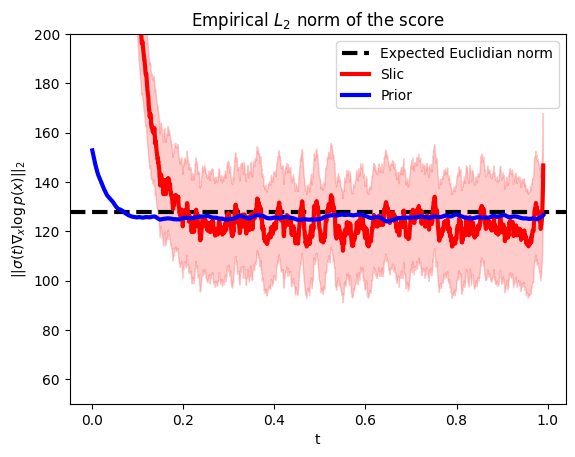

In [528]:
ts = np.linspace(0, T, len(prior_list))


window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
# plt.yscale("log")
plt.ylim(50, 200)


Text(0.5, 0, 't')

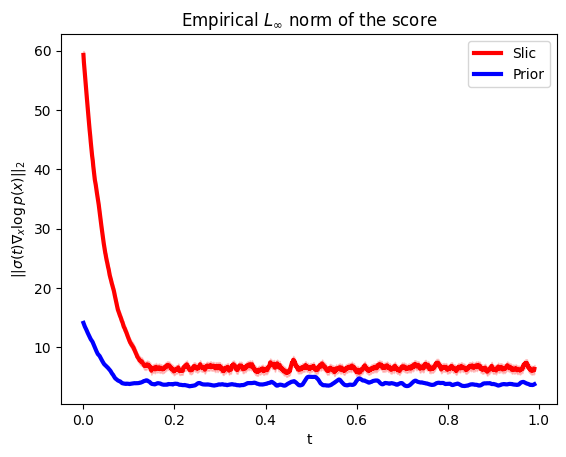

In [529]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["max"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["max"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_\infty$ norm of the score")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)
plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
# plt.ylim(50, 200)


# =============== tsVE SDE ===================

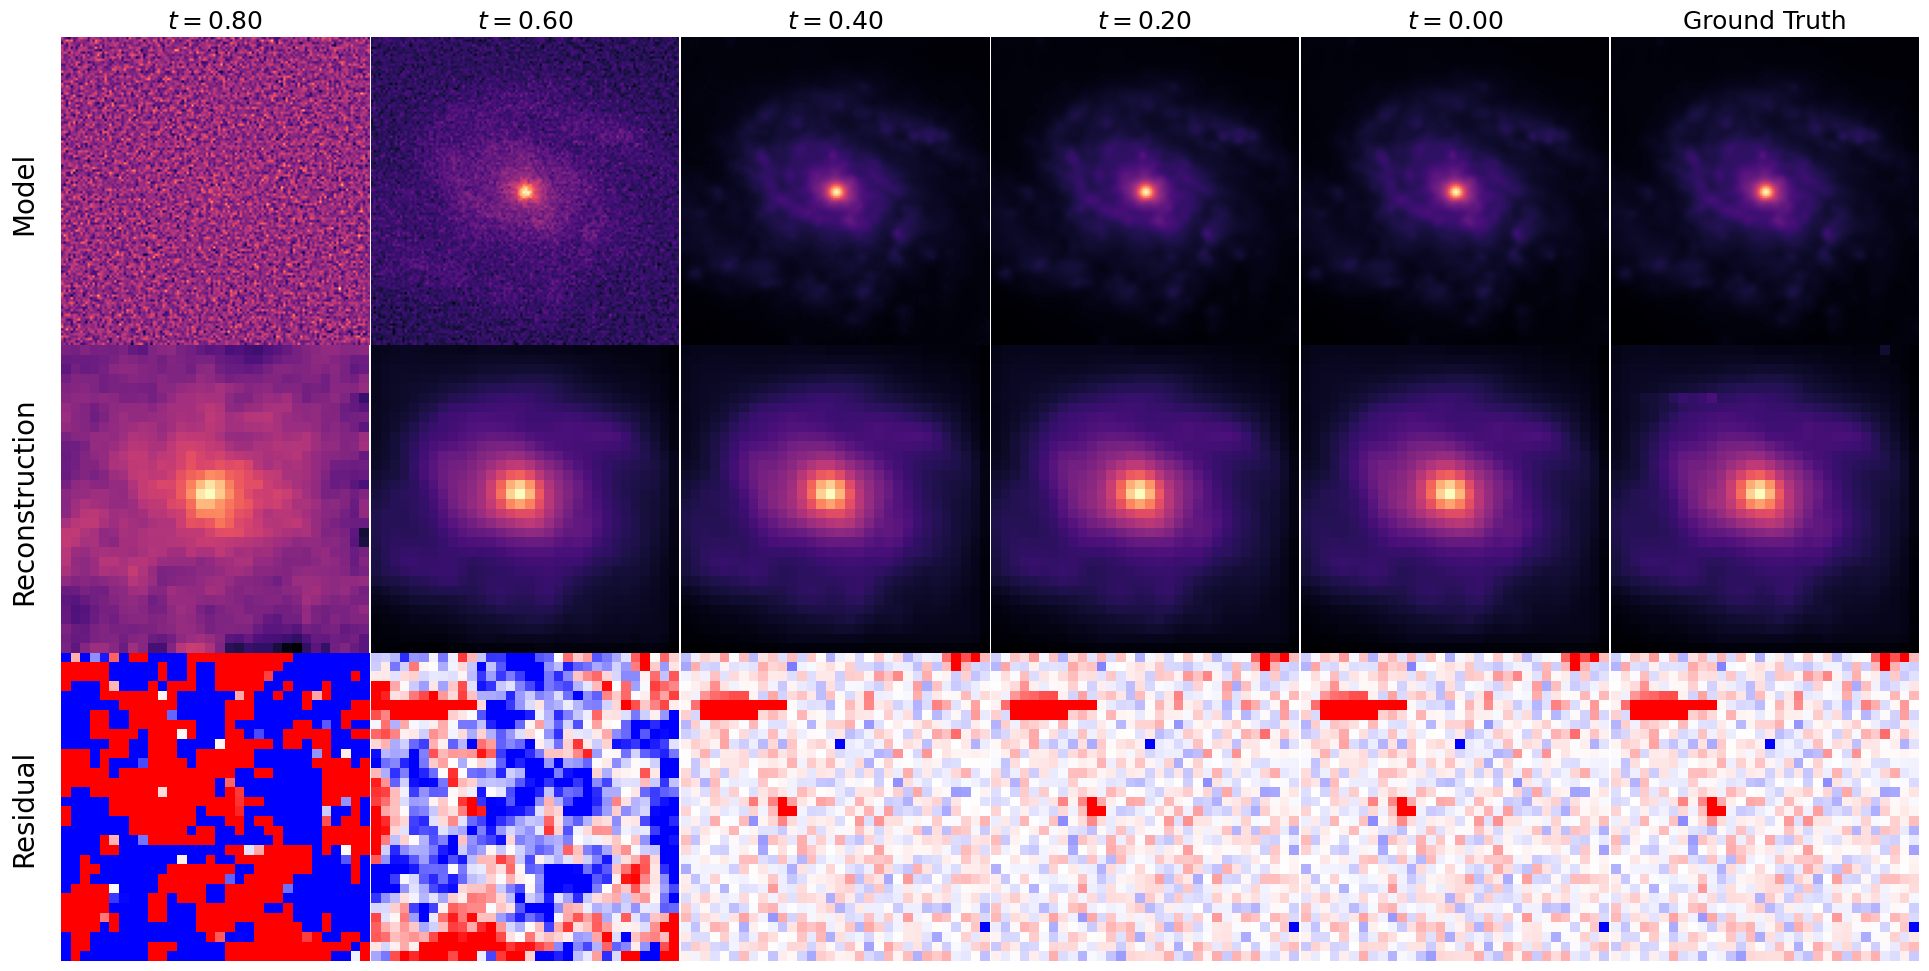

In [575]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(_x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

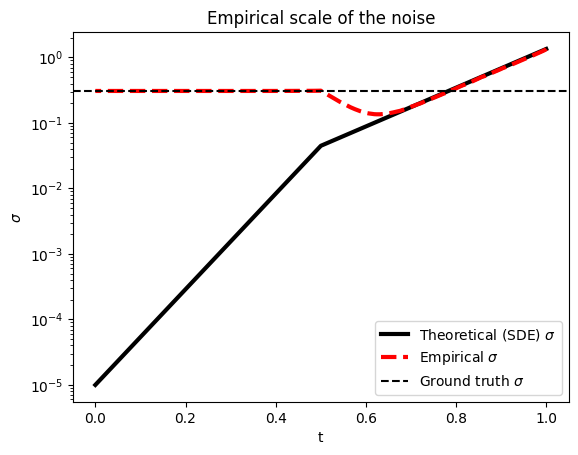

In [576]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

(50.0, 200.0)

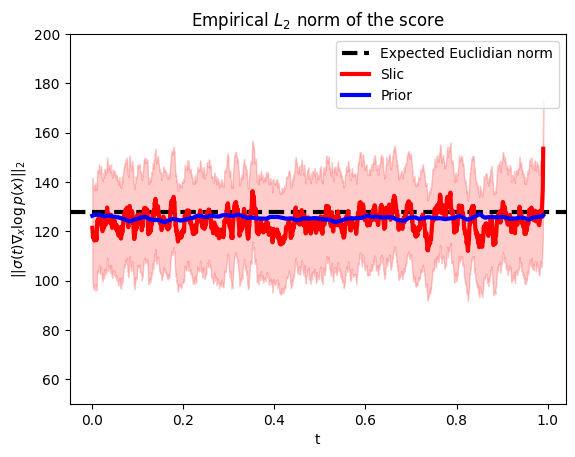

In [577]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
# plt.yscale("log")
plt.ylim(50, 200)

Text(0.5, 0, 't')

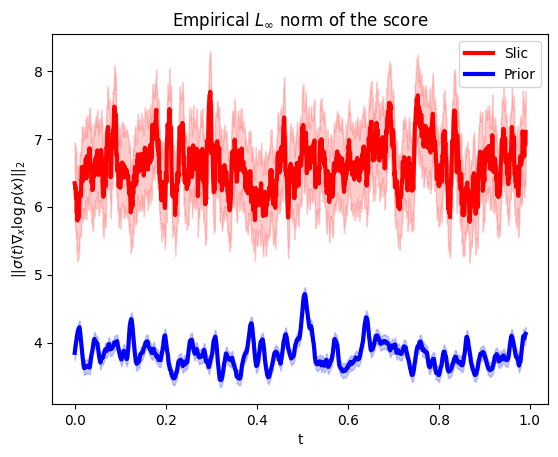

In [578]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["max"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["max"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_\infty$ norm of the score")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)
plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
# plt.ylim(50, 200)


# =============== tsVE SDE with rotated image ===================

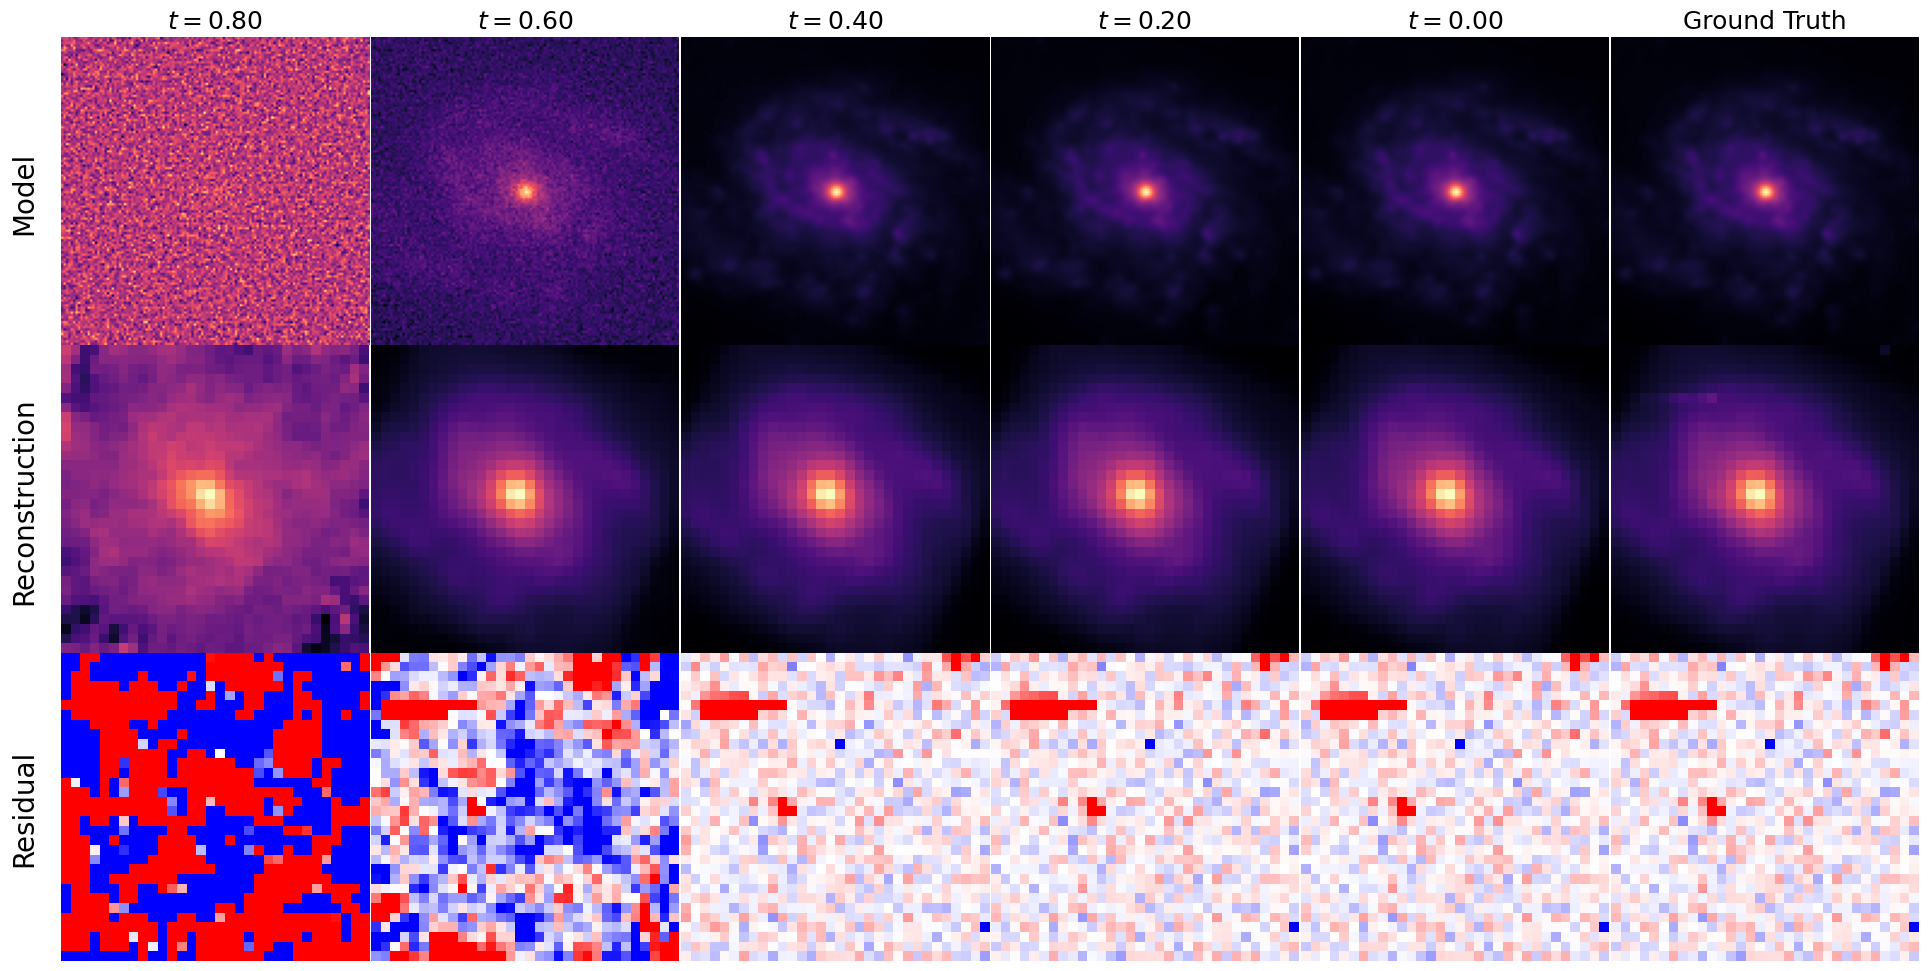

In [619]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(_x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

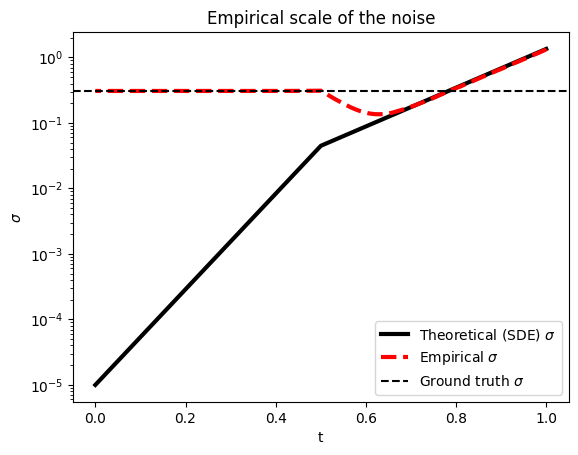

In [620]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

(50.0, 200.0)

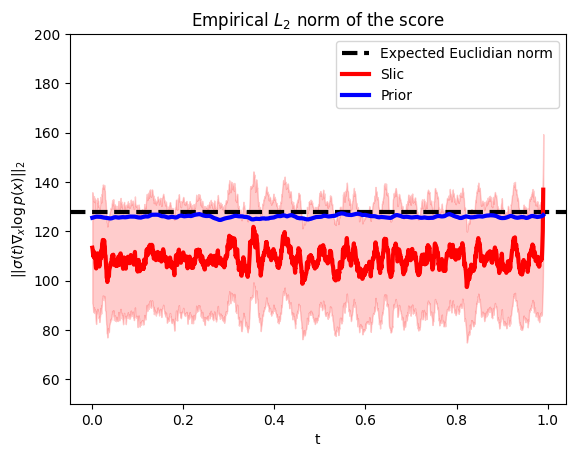

In [621]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
# plt.yscale("log")
plt.ylim(50, 200)


Text(0.5, 0, 't')

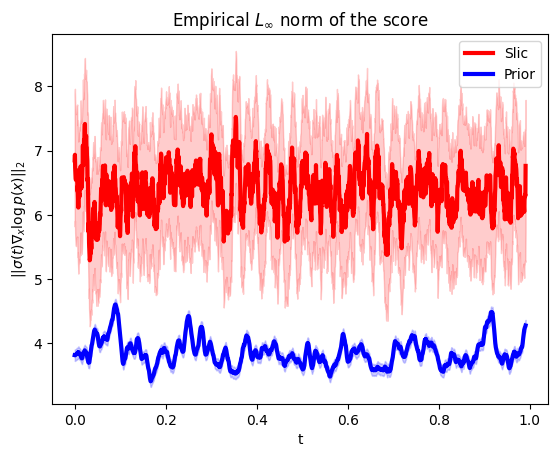

In [622]:
ts = np.linspace(0, T, len(prior_list))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["max"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["max"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_\infty$ norm of the score")

plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)
plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_\infty$")
plt.legend()
plt.xlabel("t")
# plt.ylim(50, 200)


# =============== tsVE SDE with SKIRT sigma min/max ==========

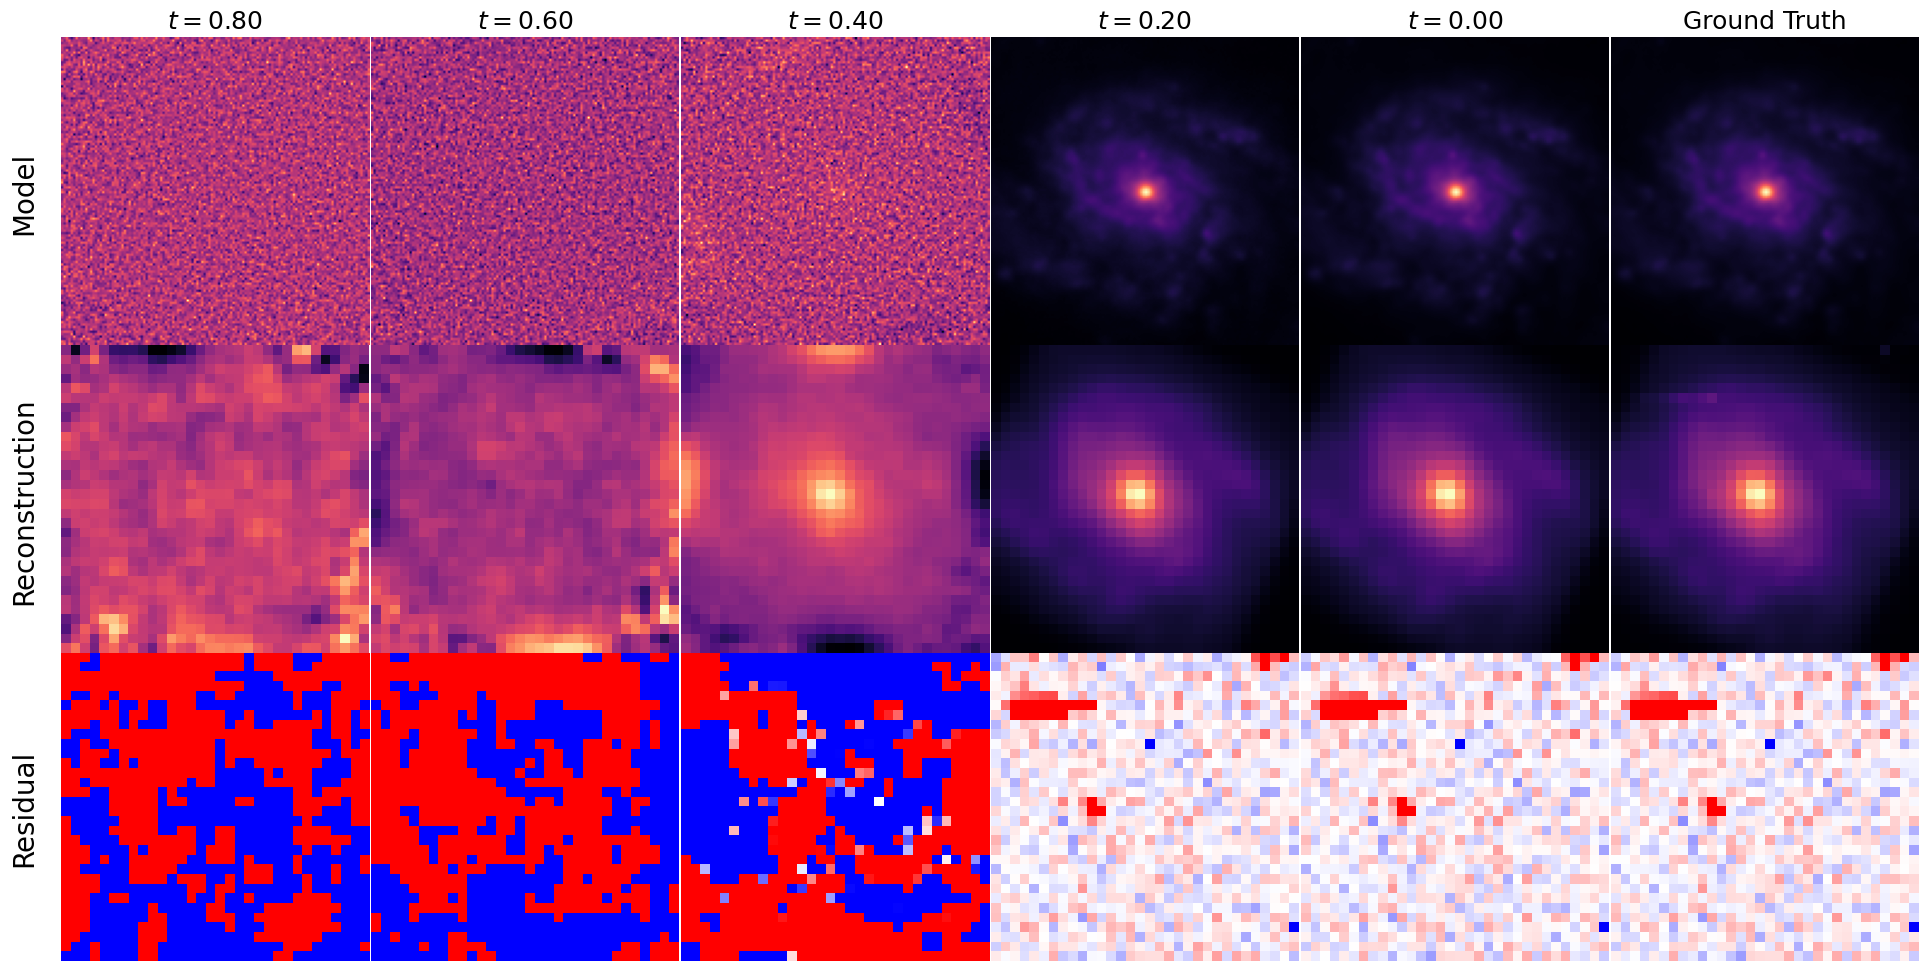

In [652]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(_x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

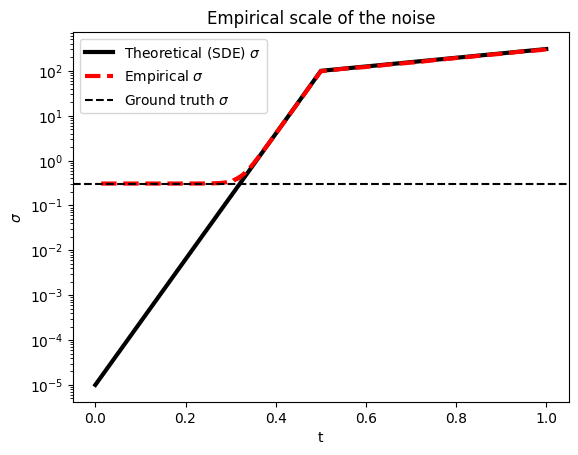

In [653]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

# =============== tsVE SDE with SKIRT sigma min/max and avg pool ==========

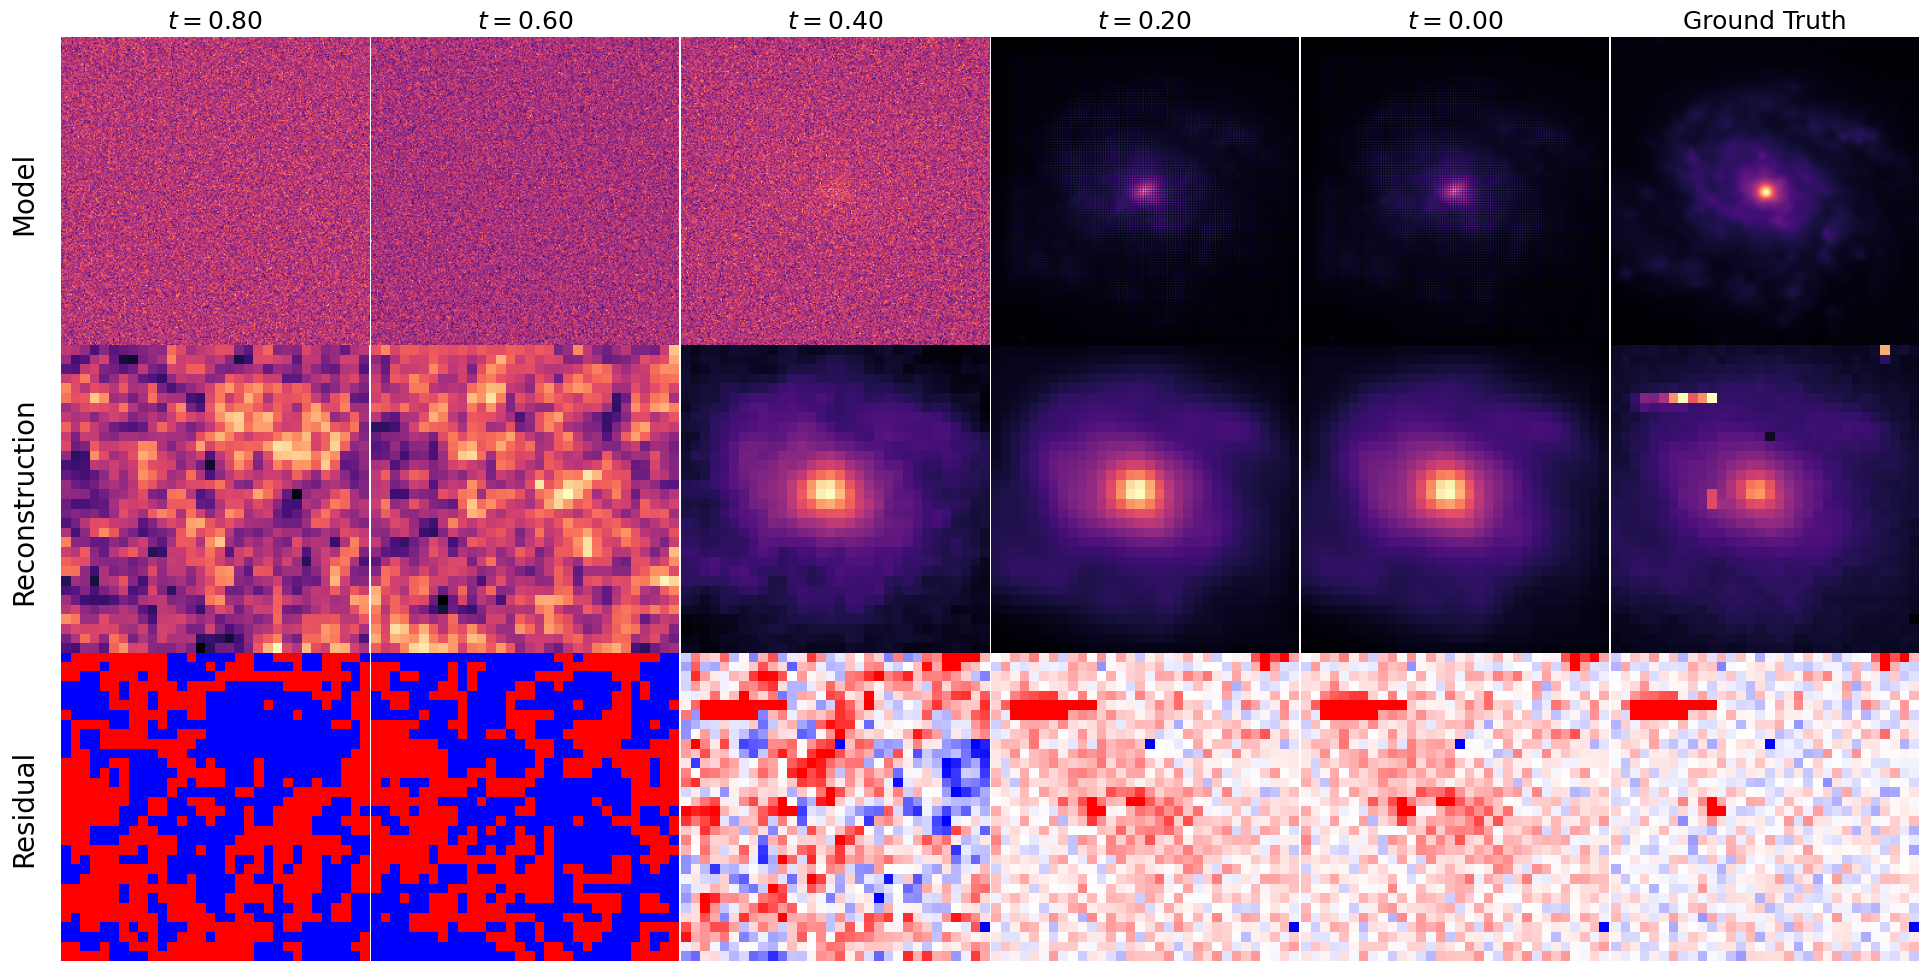

In [338]:
fig, axs = plt.subplots(3, 6, figsize=(24, 12))

ts = np.linspace(0, T, len(chain))[::-1]
k = np.random.randint(B)
for j in range(5):
    index = (j+1)*N//5-1
    
    tt = torch.tensor(ts[index])
    
    axs[0, j].imshow(chain[index][k].squeeze(), cmap="magma")
    axs[0, j].axis("off")

    _x = torch.tensor(chain[index])
    y_hat = forward_model(noise_padding_fn(_x, [noise_padding]*4, sigma=sigma(tt).item()))

    axs[1, j].imshow(y_hat[k].squeeze(), cmap="magma")
    axs[1, j].axis("off")

    axs[2, j].imshow((mu(tt).item() * observation - y_hat[k]).squeeze(), cmap="bwr", vmin=-mu(tt).item()*0.1, vmax=mu(tt).item()*0.1)
    axs[2, j].axis("off")
    
    axs[0, j].set_title(r"$t = %.2f$" % ts[index], fontsize=18)

axs[0, -1].imshow(source.squeeze(), cmap="magma")
axs[0, -1].axis("off")
axs[0, -1].set_title("Ground Truth", fontsize=18)
axs[1, -1].imshow(observation.squeeze(), cmap="magma")
axs[1, -1].axis("off")
axs[2, -1].imshow(noise.squeeze(), cmap="bwr", vmin=-0.1, vmax=0.1)
axs[2, -1].axis("off")


titles = ["Model", "Reconstruction", "Residual"]
for i in range(3):
    fig.text(0.11, 0.75 - (i / 3) / 1.3, titles[i], va='center', ha='center', rotation='vertical', fontsize=20)
plt.subplots_adjust(hspace=0, wspace=0)

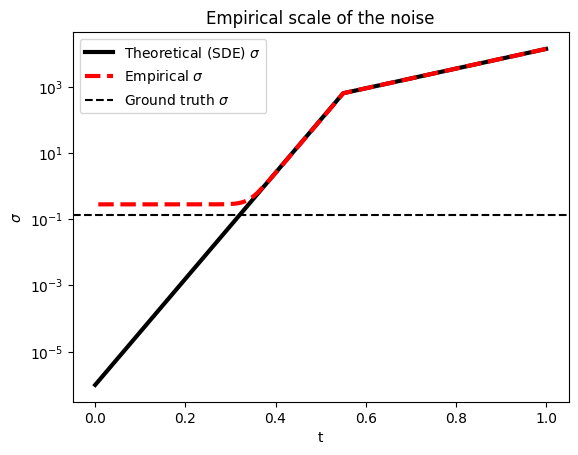

In [339]:
ts = np.linspace(0, T, len(chain))


# chain = np.stack(chain, axis=0)

plt.title("Empirical scale of the noise")
plt.plot(ts, sigma(torch.tensor(ts)).squeeze(), "k-", lw=3, label=r"Theoretical (SDE) $\sigma$")
plt.plot(ts[::-1], chain.std(axis=(1, 2, 3, 4)), "r--", lw=3, label=r"Empirical $\sigma$")
plt.axhline(x0.std(), color="k", ls="--", label=r"Ground truth $\sigma$")
plt.ylabel(r"$\sigma$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1);

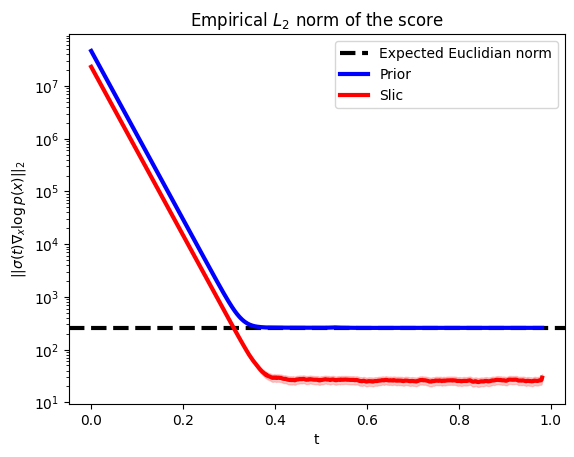

In [342]:
ts = np.linspace(0, T, len(prior_stats["norm"]))

window_size = 20
prior_mavg, prior_upper, prior_lower = moving_average_and_confidence(prior_stats["norm"], window_size)
slic_mavg, slic_upper, slic_lower = moving_average_and_confidence(slic_stats["norm"], window_size)

# Shift ts for the reduced length after moving average
ts_shifted = ts[::-1][window_size-1:]

plt.title("Empirical $L_2$ norm of the score")
plt.axhline(model_pixels, color="k", ls="--", lw=3, label="Expected Euclidian norm")
plt.plot(ts_shifted, prior_mavg, "b-", lw=3, label=r"Prior")
plt.fill_between(ts_shifted, prior_lower, prior_upper, color='b', alpha=0.2)
plt.plot(ts_shifted, slic_mavg, "r-", lw=3, label=r"Slic")
# plt.axhline(model_pixels * 2, color="r", ls="--", lw=3, label="Expected SLIC Euclidian norm")

plt.fill_between(ts_shifted, slic_lower, slic_upper, color='r', alpha=0.2)

plt.ylabel(r"$||\sigma(t) \nabla_x \log p(x) ||_2$")
plt.legend()
plt.xlabel("t")
plt.yscale("log")
# plt.ylim(0, 1.5 * model_pixels)

# Quick check of some parameters

18.0
24.0
27.0


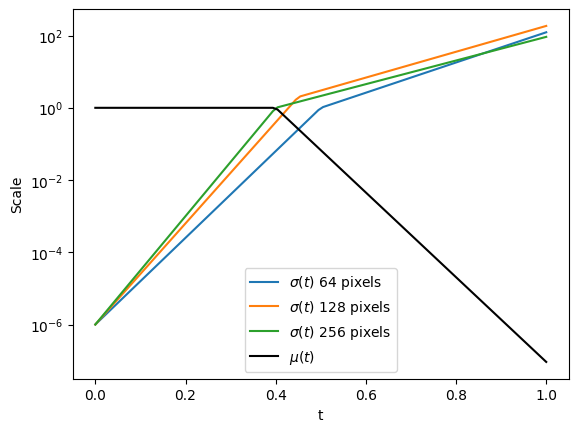

In [104]:
sigma_min = 1e-6
epsilon = 0
T = 1

t = torch.linspace(epsilon, T, 100)
# We take conservative values for each case, not necessarily band specific although we could
for i, sigma_max in enumerate([1e6, 1e8, 1e9]):
    
    t_star = [0.5, 0.45, 0.4][i]
    beta = np.round(np.log(sigma_max) * 1.3, 0)
    print(beta)
    def scale(t):
        return torch.exp(- beta * (torch.maximum(t_star*torch.ones_like(t), t) - t_star))

    def sigma(t):
        smin = np.log(sigma_min)
        smax = np.log(sigma_max)
        log_coeff = - beta * (torch.maximum(torch.ones_like(t) * t_star, t) - t_star) + (smax - smin) * t + smin
        return torch.exp(log_coeff)
    
    pixels = [64, 128, 256][i]
    plt.plot(t, sigma(t).squeeze(), label=rf"$\sigma(t)$ {pixels} pixels")
plt.plot(t, scale(t).squeeze(), color="k", label=r"$\mu(t)$")
plt.xlabel("t")
plt.ylabel("Scale")
plt.legend()
plt.yscale("log")

In [156]:
FILTER = "F105W"
# See https://www.stsci.edu/hst/instrumentation/wfc3/data-analysis/photometric-calibration/ir-photometric-calibration
if FILTER.upper() == "F105W":
    mag_zero_point = 26.264 # mag
    photplam= 12486.06
    photflam= 3.0507E-20
elif FILTER.upper() == "F125W":
    mag_zero_point = 26.264 # mag
    photplam= 12486.06
    photflam= 2.2446E-20
elif FILTER.upper() == "F160W":
    mag_zero_point = 25.936
    photplam= 15369.176 # Angstrom
    photflam= 1.9429E-20

# model_pixel_size = 0.13 / 
zero_point = -2.5 * np.log10(photflam) - mag_zero_point - 5 * np.log10(photplam) + 18.6921
factor = 10**((zero_point - 8.9)/2.5) / 1e6 # conversion from electron/sec to micro Jy / arcsec^2 for the observation
factor

0.05419879897763825